In [2]:
import numpy as np
import matplotlib.pyplot as plt
from model import * 
from utils import *

In [3]:
# ============================================================
# 2-site, half-filled 1D Hubbard model
# ============================================================

U = 4.0
t = 1.0

model = Hubbard1D(
    nsites=2,
    nelectrons=(1, 1),
    U=U,
    t=t,
    periodic=False,
)

# Exact N-electron ground state
E0, psi0 = model.ground_state()

print(f"Exact ground-state energy = {E0:.10f} Ha")

Exact ground-state energy = -0.8284271247 Ha


In [4]:
# ============================================================
# Exact FCI spectral moments
# ============================================================

nmom = 10

fci_moments = fci_spectral_moments(
    model=model,
    nmom=nmom,
)

hole_moments = fci_moments[
    "hole_moments"
]

particle_moments = fci_moments[
    "particle_moments"
]

print(
    "Hole moments shape:",
    hole_moments.shape,
)

print(
    "Particle moments shape:",
    particle_moments.shape,
)

print("\nZeroth hole moment:")
print(hole_moments[0])

print("\nZeroth particle moment:")
print(particle_moments[0])

Hole moments shape: (11, 2, 2)
Particle moments shape: (11, 2, 2)

Zeroth hole moment:
[[1.         0.70710678]
 [0.70710678 1.        ]]

Zeroth particle moment:
[[ 1.         -0.70710678]
 [-0.70710678  1.        ]]


In [5]:
# ============================================================
# Zeroth-moment sum rule
#
# T_h^(0) + T_p^(0) = 2 I
#
# because these are spin-summed spatial/site moments.
# ============================================================

T0_sum = (
    hole_moments[0]
    + particle_moments[0]
)

expected = (
    2.0
    * np.eye(model.nsites)
)

sum_rule_error = np.linalg.norm(
    T0_sum - expected
)

print("\nT_h(0) + T_p(0):")
print(T0_sum)

print(
    "\nZeroth-moment sum-rule error:",
    sum_rule_error,
)


T_h(0) + T_p(0):
[[2. 0.]
 [0. 2.]]

Zeroth-moment sum-rule error: 3.1401849173675502e-15


In [6]:
# ============================================================
# Frequency grid
# ============================================================

omega = np.linspace(
    -10.0,
    10.0,
    4001,
)

eta = 0.05


# ============================================================
# One-body Hubbard integrals
#
# Required for Galitskii-Migdal energy.
# ============================================================

h1, h2 = (
    model.one_two_electron_integrals()
)


# ============================================================
# Moment-derived Green's function
# ============================================================

moment_gf = greens_function_from_moments(
    hole_moments=hole_moments,
    particle_moments=particle_moments,
    omega_grid=omega,
    one_body_integrals=h1,
    constant_energy=0.0,
    eta=eta,

    # nmom=10 gives moments 0,...,10.
    # nblocks=5 requires moments 0,...,9.
    nblocks=5,

    threshold=1e-10,
    verbose=False,
)


G_moment = moment_gf["G"]

A_moment = moment_gf["A"]


print(
    "Moment-derived GM energy:",
    moment_gf[
        "galitskii_migdal"
    ]["total"],
)

print(
    "Exact FCI energy:",
    E0,
)

print(
    "GM - FCI:",
    moment_gf[
        "galitskii_migdal"
    ]["total"] - E0,
)

Moment-derived GM energy: -0.828427124746189
Exact FCI energy: -0.8284271247461901
GM - FCI: 1.1102230246251565e-15


In [7]:
# ============================================================
# Exact Lehmann Green's function
# ============================================================

# -----------------------
# Spin-up sectors
# -----------------------

model_plus_up = Hubbard1D(
    nsites=2,
    nelectrons=(2, 1),
    U=U,
    t=t,
    periodic=False,
)

model_minus_up = Hubbard1D(
    nsites=2,
    nelectrons=(0, 1),
    U=U,
    t=t,
    periodic=False,
)

lehmann_up = LehmannGF(
    model_N=model,
    model_N_plus=model_plus_up,
    model_N_minus=model_minus_up,
)


# -----------------------
# Spin-down sectors
# -----------------------

model_plus_down = Hubbard1D(
    nsites=2,
    nelectrons=(1, 2),
    U=U,
    t=t,
    periodic=False,
)

model_minus_down = Hubbard1D(
    nsites=2,
    nelectrons=(1, 0),
    U=U,
    t=t,
    periodic=False,
)

lehmann_down = LehmannGF(
    model_N=model,
    model_N_plus=model_plus_down,
    model_N_minus=model_minus_down,
)

In [8]:
# ============================================================
# Spin-summed, site-traced exact Lehmann spectral function
# ============================================================

A_lehmann = np.zeros_like(
    omega,
    dtype=float,
)

G_lehmann = np.zeros_like(
    omega,
    dtype=complex,
)


for site in range(model.nsites):

    # Spin up
    G_up = lehmann_up.green_function(
        site=site,
        spin=0,
        omega_grid=omega,
        eta=eta,
    )

    # Spin down
    G_down = lehmann_down.green_function(
        site=site,
        spin=1,
        omega_grid=omega,
        eta=eta,
    )

    G_lehmann += (
        G_up
        + G_down
    )


A_lehmann = (
    -1.0 / np.pi
    * np.imag(G_lehmann)
)

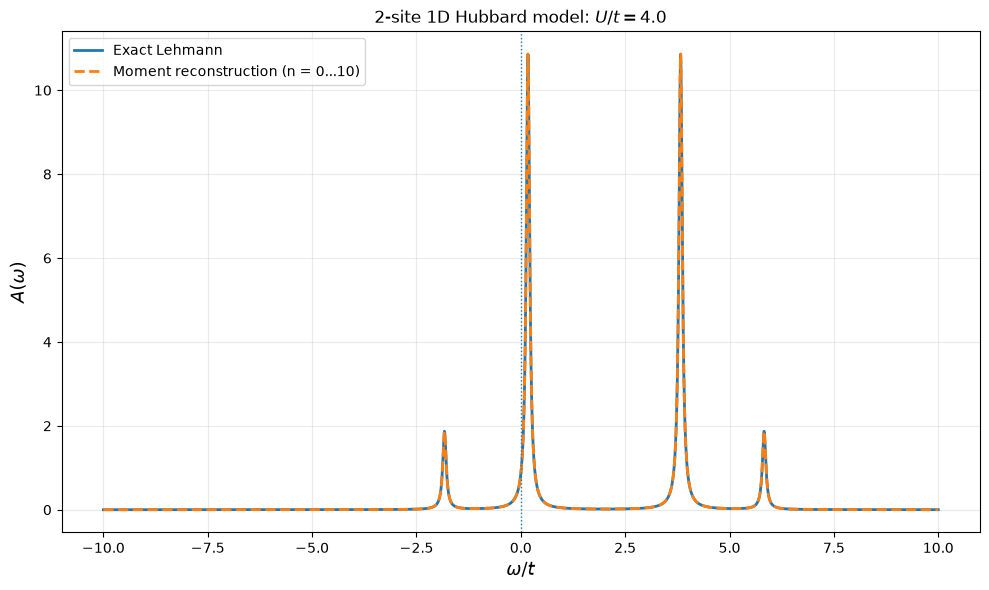

In [10]:
# ============================================================
# Plot exact Lehmann vs moment-derived spectrum
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    omega,
    A_lehmann,
    label="Exact Lehmann",
    linewidth=2.0,
)

plt.plot(
    omega,
    A_moment,
    "--",
    label=f"Moment reconstruction (n = 0...{nmom})",
    linewidth=2.0,
)

plt.axvline(
    0.0,
    linewidth=1.0,
    linestyle=":",
)

plt.xlabel(
    r"$\omega/t$",
    fontsize=13,
)

plt.ylabel(
    r"$A(\omega)$",
    fontsize=13,
)

plt.title(
    rf"2-site 1D Hubbard model: "
    rf"$U/t={U/t:.1f}$"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()